# Ablation Study — Component Contribution

Compare each single-component model against the full `LokyStackerV10RSTSFRandom` ensemble.

In [1]:
import matplotlib.pyplot as plt
import polars as pl
from aeon.visualisation import plot_critical_difference
from pathlib import Path
from tscglue.utils import load_s3_parquet_cached

Path("figures").mkdir(parents=True, exist_ok=True)

FULL_MODEL = "loky-stacker-v10-rstsf-random"
ABLATION_MODELS = [
    "ablation-multirockethydra-bestk-p-ridgecv",
    "ablation-quant-etc",
    "ablation-rdst-p-ridgecv",
    "ablation-rstsf-random-etc",
    "ablation-fm-p-ridgecv",
]
ALL_MODELS = ABLATION_MODELS + [FULL_MODEL]

SHORT_NAMES = {
    "ablation-multirockethydra-bestk-p-ridgecv": "MR-Hydra",
    "ablation-quant-etc":                        "Quant-ETC",
    "ablation-rdst-p-ridgecv":                   "RDST",
    "ablation-rstsf-random-etc":                 "RSTSF-ETC",
    "ablation-fm-p-ridgecv":                     "FM",
    FULL_MODEL:                                  "Full ensemble",
}

In [2]:
raw = load_s3_parquet_cached()
df = raw.filter(pl.col("model").is_in(ALL_MODELS))
print(f"Loaded {len(df)} rows across {df['dataset'].n_unique()} datasets")
df.group_by("model").agg(
    pl.len().alias("n_rows"),
    pl.col("dataset").n_unique().alias("n_datasets"),
).sort("model")

Loaded 20160 rows across 112 datasets


model,n_rows,n_datasets
str,u32,u32
"""ablation-fm-p-ridgecv""",3360,112
"""ablation-multirockethydra-best…",3360,112
"""ablation-quant-etc""",3360,112
"""ablation-rdst-p-ridgecv""",3360,112
"""ablation-rstsf-random-etc""",3360,112
"""loky-stacker-v10-rstsf-random""",3360,112


112


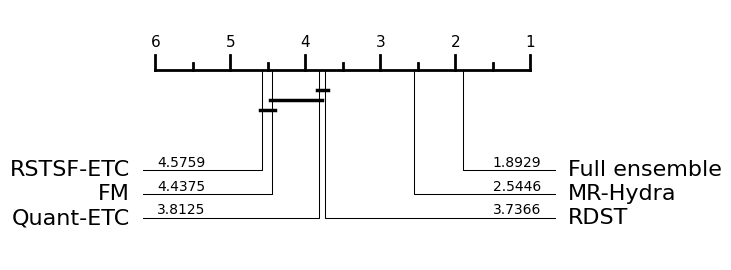

In [3]:
# Pivot: mean accuracy per dataset per model (averaged over folds)
perf = (
    df.group_by(["dataset", "model"])
    .agg(pl.col("test_accuracy").mean())
    .pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean")
    .drop_nulls()
)

print(len(perf))

# Rename to short names for the plot
perf_renamed = perf.rename({m: SHORT_NAMES[m] for m in ALL_MODELS if m in perf.columns})
clsf = perf_renamed.select([SHORT_NAMES[m] for m in ALL_MODELS if SHORT_NAMES[m] in perf_renamed.columns])

plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig("figures/ablation_cd.pdf", bbox_inches="tight", pad_inches=0)

In [4]:
perf = (
    df.group_by(["dataset", "model"])
    .agg(pl.col("test_accuracy").mean())
    .pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean")
)
perf

dataset,ablation-quant-etc,ablation-rdst-p-ridgecv,ablation-fm-p-ridgecv,loky-stacker-v10-rstsf-random,ablation-rstsf-random-etc,ablation-multirockethydra-bestk-p-ridgecv
str,f64,f64,f64,f64,f64,f64
"""PigArtPressure""",0.886859,0.922115,0.797596,0.935417,0.740224,0.973237
"""Earthquakes""",0.752998,0.736691,0.740767,0.747962,0.747962,0.746283
"""StarLightCurves""",0.98069,0.980816,0.980055,0.982196,0.979671,0.981735
"""Phoneme""",0.367423,0.367423,0.367423,0.367423,0.367423,0.367423
"""SmoothSubspace""",0.988667,0.997333,0.978222,0.992444,0.985778,0.982
…,…,…,…,…,…,…
"""PigCVP""",0.65641,0.897756,0.747436,0.853526,0.637821,0.925481
"""DiatomSizeReduction""",0.952179,0.952179,0.952179,0.952179,0.952179,0.952179
"""FreezerRegularTrain""",0.999462,0.998737,0.993778,0.999567,0.999474,0.998924
